In [1]:
import numpy as np
from matplotlib import pyplot as plt
from scipy.stats import  ncx2
import pandas as pd
from numba import  njit

# Примеры

In [2]:
class StochasticProcess:
    def __init__(self, params, T, Nx, Nt, init_state = None):
        self.params = params
        self.T = T
        self.Nx = Nx # Number of trajectories
        self.Nt = Nt # Number of discretization steps
        self.init_state = init_state

    #Wiener Process by default
    #use @staticmethod for numba compatibility with @njit
    @staticmethod
    @njit
    def bxt(x, t, params):
        return 0

    @staticmethod
    @njit
    def sigmaxt(x, t, params):
        return 1

    @staticmethod
    @njit
    def bxt_x(x, t, params):
        return 0

    @staticmethod
    @njit
    def bxt_xx(x, t, params):
        return 0

    @staticmethod
    @njit
    def sigmaxt_x(x, t, params):
        return 0

    @staticmethod
    @njit
    def sigmaxt_xx(x, t, params):
        return 0

    @staticmethod
    @njit
    def bxt_t(x, t, params):
        return 0

    def DefaultInitState(self):
        return np.zeros(self.Nx)

    def EulerSolution(self, dwt = None):
        dt = self.T / self.Nt
        t_data = np.linspace(0, self.T, self.Nt + 1)
        x_data = np.zeros((self.Nt + 1, self.Nx))

        if dwt is None:
            dwt = np.random.normal(0, 1, size = (self.Nt, self.Nx)) * np.sqrt(dt)

        if self.init_state is None:
            x_data[0] = self.DefaultInitState()
        else:
            x_data[0] = self.init_state

        for i in range(1, self.Nt + 1):
            x_data[i] = x_data[i - 1] + self.bxt(x_data[i - 1], t_data[i - 1], self.params) * dt +\
                        self.sigmaxt(x_data[i - 1], t_data[i - 1], self.params) * dwt[i - 1]
        return t_data, x_data

    def Milstein2Solution(self, dwt = None):
        dt = self.T / self.Nt
        t_data = np.linspace(0, self.T, self.Nt + 1)
        x_data = np.zeros((self.Nt + 1, self.Nx))

        if dwt is None:
            dwt = np.random.normal(0, 1, size = (self.Nt, self.Nx)) * np.sqrt(dt)

        if self.init_state is None:
            x_data[0] = self.DefaultInitState()
        else:
            x_data[0] = self.init_state

        for i in range(1, self.Nt + 1):
            x_data[i] = x_data[i - 1] + (self.bxt(x_data[i - 1], t_data[i - 1], self.params) - 1/2 * self.sigmaxt(x_data[i - 1], t_data[i - 1], self.params) * self.sigmaxt_x(x_data[i - 1], t_data[i - 1], self.params)) * dt +\
                        self.sigmaxt(x_data[i - 1], t_data[i - 1], self.params) * dwt[i - 1] + 1/2 * self.sigmaxt(x_data[i - 1], t_data[i - 1], self.params) * self.sigmaxt_x(x_data[i - 1], t_data[i - 1], self.params) * dwt[i - 1]**2 +\
                        (1/2 * self.bxt(x_data[i - 1], t_data[i - 1], self.params) * self.sigmaxt_x(x_data[i - 1], t_data[i - 1], self.params) + 1/2 * self.bxt_x(x_data[i - 1], t_data[i - 1], self.params) * self.sigmaxt(x_data[i - 1], t_data[i - 1], self.params) +\
                        1/4 * self.sigmaxt(x_data[i - 1], t_data[i - 1], self.params)**2 * self.sigmaxt_xx(x_data[i - 1], t_data[i - 1], self.params)) * dt * dwt[i - 1] +\
                        (1/2 * self.bxt(x_data[i - 1], t_data[i - 1], self.params) * self.bxt_x(x_data[i - 1], t_data[i - 1], self.params) + 1/4 * self.bxt_xx(x_data[i - 1], t_data[i - 1], self.params) * self.sigmaxt(x_data[i - 1], t_data[i - 1], self.params)**2) * dt**2
        return t_data, x_data


class CIRprocess(StochasticProcess):
    def __init__(self, params, T, Nx, Nt, init_state = None):
        super().__init__(params, T, Nx, Nt, init_state)

    # params = [theta1, theta2, theta3]
    @staticmethod
    @njit
    def bxt(x, t, params):
        return params[0] - params[1] * x

    @staticmethod
    @njit
    def sigmaxt(x, t, params):
        return params[2] * np.sqrt(np.maximum(x,0))

    @staticmethod
    @njit
    def bxt_x(x, t, params):
        return -params[1]

    @staticmethod
    @njit
    def sigmaxt_x(x, t, params):
        return params[2] * 1/2 * 1/np.sqrt(np.maximum(x,0))

    @staticmethod
    @njit
    def sigmaxt_xx(x, t, params):
        return -params[2] * 1/4 * 1/np.maximum(x,0)**(3/2)

    def DefaultInitState(self):
        return self.params[0] / self.params[1] * np.ones(self.Nx)

    def ExactSolution(self, dwt = None):
        dt = self.T / self.Nt
        t_data = np.linspace(0, self.T, self.Nt + 1)
        x_data = np.zeros((self.Nt + 1, self.Nx))

        theta1 = self.params[0]
        theta2 = self.params[1]
        theta3 = self.params[2]

        if self.init_state is None:
            x_data[0] = self.DefaultInitState()
        else:
            x_data[0] = self.init_state

        if dwt is None:
            dwt = np.random.normal(0, 1, size = (self.Nt, self.Nx)) * np.sqrt(dt)

        Ito_integral_sum = np.zeros(self.Nx)
        for i in range(1, self.Nt + 1):
            Determinated_part = (x_data[0] - theta1 / theta2) * np.exp(-theta2 * t_data[i]) + theta1/theta2
            #avoiding exp overflow
            Ito_integral_sum = (Ito_integral_sum + theta3 * np.sqrt(np.maximum(x_data[i - 1], 0)) * dwt[i - 1]) * np.exp(-theta2 * dt)
            x_data[i] = Determinated_part + Ito_integral_sum
        return t_data, x_data

    def StationaryState(self):
        theta1 = self.params[0]
        theta2 = self.params[1]
        theta3 = self.params[2]

        k = theta2
        theta = theta1 / theta2
        sigma = theta3

        c = 2 * k / (sigma**2)
        u = 0
        q = 2 * k * theta / sigma**2 - 1

        return ncx2.rvs(2 * q + 2, 2 * u, size = self.Nx) / (2 * c)

    def ProcessDistribution(self, x, t, x0, t0):
        theta1 = self.params[0]
        theta2 = self.params[1]
        theta3 = self.params[2]

        k = theta2
        theta = theta1 / theta2
        sigma = theta3

        c = 2 * k / (sigma**2 * (1 - np.exp(-k * (t - t0))))
        u = c * x0 * np.exp(-k * (t - t0))
        #v = c * x
        q = 2 * k * theta / sigma**2 - 1
        return ncx2.pdf(2 * c * x, 2 * q + 2, 2 * u) * (2 * c) #2c is normalazing constant

    def StationaryDistribution(self, x):
        theta1 = self.params[0]
        theta2 = self.params[1]
        theta3 = self.params[2]

        k = theta2
        theta = theta1 / theta2
        sigma = theta3

        c = 2 * k / (sigma**2)
        u = 0
        q = 2 * k * theta / sigma**2 - 1
        return ncx2.pdf(2 * c * x, 2 * q + 2, 2 * u) * (2 * c)

Task 1. Simulate a Cox-Ingersoll-Ross (CIR) model
$$
dX_t = (\theta_1 - \theta_2 X_t)dt + \theta_3 \sqrt{X_t}dW_t
$$
with $\theta = (6, 2, 1)$, and choose the bandwidth according to Scott’s rule and implement the non-parametric kernel estimation for stationary density of the CIR model.

Plot in a graph the true stationary density against the estimated one for
*   $n=1000$, $\Delta_n=1$,
*   $n=15000$, $\Delta_n=0.01$.



In [3]:
def StationaryDistributionKernelEstimator(x, x_data, delta = None):
    n = len(x_data)
    m = 1

    hn = 1

    if delta is None:
        hn = np.std(x_data) * n**(-1 / (m + 4))
    else:
        hn = delta

    pi = np.zeros(len(x))

    for j in range(0, len(x)):
        K = 1/np.sqrt(2 * np.pi) * np.exp(-1/2 * (x[j] - x_data)**2 / hn**2)

        pi[j] = 1 / (n * hn) * np.sum(K)

    return pi

In [4]:
'''Расчёт на 1 траектрии
Для обеспечения стационарности задаём T очень большим. T/Nt = delta t - шаг дискретизации по времени
'''

Nx = 1
Nt = 100000
T = 1000

params_CIR = [6, 2, 1]

CIRp = CIRprocess(params_CIR, T, Nx, Nt)
CIRp.init_state = CIRp.StationaryState()
t_data, x_data_CIR = CIRp.ExactSolution()

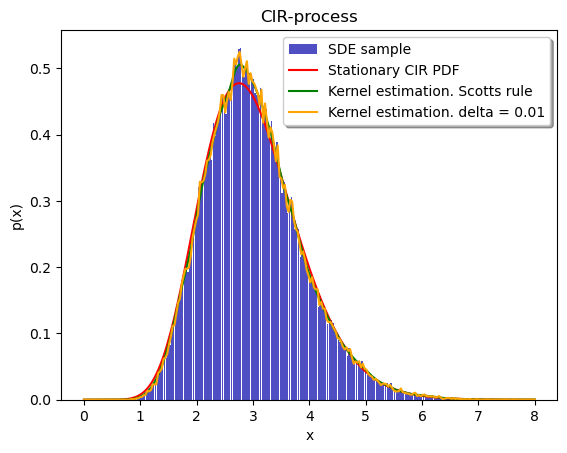

In [5]:
n = np.random.randint(0, Nt)
fig, ax = plt.subplots()
x_data = np.linspace(0, 8, 250)

i = np.random.randint(0, Nt)

n, bins, patches = ax.hist(x_data_CIR.flatten(), bins=x_data, density=True, color='#0504aa', alpha=0.7, rwidth=0.85, label = 'SDE sample')
ax.set_xlabel('x')
ax.set_ylabel('p(x)')
ax.set_title(f'CIR-process', loc = 'center')

ax.plot(x_data, CIRp.StationaryDistribution(x_data), label = 'Stationary CIR PDF', color = 'red')
#ax.plot(x_data, CIRp.ProcessDistribution(x_data, T * i / Nt, x0, 0), label = 'Stationary CIR PDF', color = 'red')

ax.plot(x_data, StationaryDistributionKernelEstimator(x_data, x_data_CIR.flatten()), label = f'Kernel estimation. Scotts rule', color = 'green')

d = 0.01
ax.plot(x_data, StationaryDistributionKernelEstimator(x_data, x_data_CIR.flatten(), delta = d),
        label = f'Kernel estimation. delta = {d}', color = 'orange')

ax.legend(loc = 'upper right', fancybox = True, shadow = True)
plt.show()

In [6]:
'''Расчёт на Nx траектриях
Для обеспечения стационарности задаём число траекторий Nx большим, а так же
в качестве начального состояния задаём стационарное состояние
'''
Nx = 15000
Nt = 300

T = 1

params_CIR = [6, 2, 1]

CIRp = CIRprocess(params_CIR, T, Nx, Nt)
CIRp.init_state = CIRp.StationaryState()
t_data, x_data_CIR = CIRp.ExactSolution()

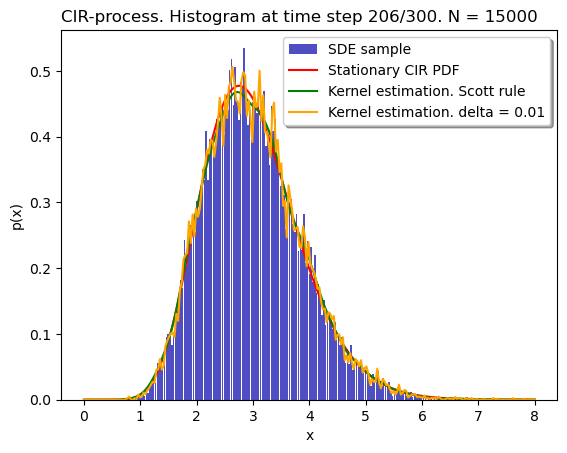

In [7]:
n = np.random.randint(0, Nt)
fig, ax = plt.subplots()
x_data = np.linspace(0, 8, 250)

i = np.random.randint(0, Nt)

n, bins, patches = ax.hist(x_data_CIR[i], bins=x_data, density=True, color='#0504aa', alpha=0.7, rwidth=0.85, label = 'SDE sample')
ax.set_xlabel('x')
ax.set_ylabel('p(x)')
ax.set_title(f'CIR-process. Histogram at time step {i}/{Nt}. N = {Nx}', loc = 'left')

ax.plot(x_data, CIRp.StationaryDistribution(x_data), label = 'Stationary CIR PDF', color = 'red')
#ax.plot(x_data, CIRp.ProcessDistribution(x_data, T * i / Nt, x0, 0), label = 'Stationary CIR PDF', color = 'red')

ax.plot(x_data, StationaryDistributionKernelEstimator(x_data, x_data_CIR[i]), label = f'Kernel estimation. Scott rule', color = 'green')

d = 0.01
ax.plot(x_data, StationaryDistributionKernelEstimator(x_data, x_data_CIR[i], delta = d),
        label = f'Kernel estimation. delta = {d}', color = 'orange')

ax.legend(loc = 'upper right', fancybox = True, shadow = True)
plt.show()

Task. Estimate the quality of the obtained approximations with statistical criteria and provide conclusions.

In [8]:
# your code

Task. Study the effect of the bandwidth $h_n$ and the mesh $∆_n$ on the kernel estimator and plot a 3D graph.

In [9]:
# your code

Task 2. Implement a non-parametric drift estimator

$$
\hat{b}_n(x) = \frac{\sum_{i=0}^{n-1} K\left(\frac{x-X_i}{h_n}\right)(X_{i+1}-X_i)} {\Delta_n \sum_{i=0}^{n-1} K\left(\frac{x-X_i}{h_n}\right)}
$$

and diffusion estimator
$$
\hat{\sigma}^2_n(x) = \frac{\sum_{i=0}^{n-1} K\left(\frac{x-X_i}{h_n}\right)(X_{i+1}-X_i)^2} {\Delta_n \sum_{i=0}^{n-1} K\left(\frac{x-X_i}{h_n}\right)}.$$


for the model from previous item and plot two graphs.
Use the

*  Gaussian kernel $K(u) = \frac{1}{\sqrt{2\pi}} \exp \left(-\frac{1}{2}u^2\right)$,
*  Uniform kernel $K(u)=1/2$,
*  Epanechnikov (parabolic) kernel $K(u)=\frac{3}{4}(1-u^2)$.


In [10]:
from typing import Literal

def NormalKernel(z):
    return 1/np.sqrt(2 * np.pi) * np.exp(-1/2 * z**2)

def UniformKernel(z):
    return 1/2 * np.ones_like(z)

def ParabolicKernel(z):
    return 3/4 * (1 - z**2)

def DiffusionKernelEstimator(x, x_data, delta = None, method: Literal['normal', 'uniform', 'parabolic'] = 'normal'):
    n = len(x_data)
    m = 1

    hn = 1

    hn = np.std(x_data) * n**(-1 / (m + 4))

    s2 = np.zeros(len(x))

    for j in range(0, len(x)):
        K1 = 0
        K2 = 0
        z = (x[j] - x_data)**2 / hn**2
        if method == 'normal':
            K = NormalKernel(z)
        elif method == 'uniform':
            K = UniformKernel(z)
        elif method == 'parabolic':
            K = ParabolicKernel(z)
        else:
            raise ValueError(f"method = {method} not implemented")

        K1 = np.sum(K[0:n-1] * (x_data[1:] - x_data[0:n-1])**2)
        K2 = np.sum(K)
        if K2 == 0:
            s2[j] = 0
        else:
            s2[j] = K1 / K2

    if delta is None:
        delta = 1

    return s2 / delta

def DriftKernelEstimator(x, x_data, delta = None, method: Literal['normal', 'uniform', 'parabolic'] = 'normal'):
    n = len(x_data)
    m = 1

    hn = 1

    hn = np.std(x_data) * n**(-1 / (m + 4))

    s2 = np.zeros(len(x))

    for j in range(0, len(x)):
        K1 = 0
        K2 = 0
        z = (x[j] - x_data)**2 / hn**2
        if method == 'normal':
            K = NormalKernel(z)
        elif method == 'uniform':
            K = UniformKernel(z)
        elif method == 'parabolic':
            K = ParabolicKernel(z)
        else:
            raise ValueError(f"method = {method} not implemented")

        K1 = np.sum(K[0:n-1] * (x_data[1:] - x_data[0:n-1]))
        K2 = np.sum(K)
        if K2 == 0:
            s2[j] = 0
        else:
            s2[j] = K1 / K2

    if delta is None:
        delta = 1

    return s2 / delta

In [11]:
Nx = 1
Nt = 100000

T = 1000

x_data = np.linspace(0, 6, 200)

params_CIR = [6, 2, 1]

CIRp = CIRprocess(params_CIR, T, Nx, Nt)
t_data, x_data_CIR = CIRp.ExactSolution()

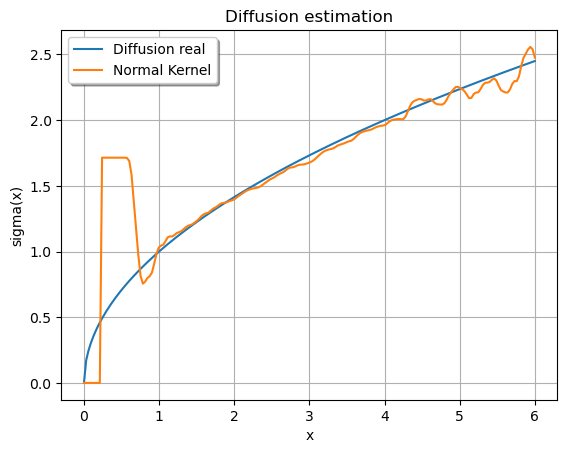

In [12]:
sigma_data = CIRp.sigmaxt(x_data, 0, CIRp.params)

plt.plot(x_data, sigma_data, label = 'Diffusion real')


diffke = DiffusionKernelEstimator(x_data, x_data_CIR.flatten(), T/Nt, 'normal')
plt.plot(x_data, np.sqrt(diffke), label = 'Normal Kernel')

#diffke = DiffusionKernelEstimator(x_data, x_data_CIR.flatten(), T/Nt, 'parabolic')
#plt.plot(x_data, np.sqrt(diffke), label = 'Parabolic Kernel')

#diffke = DiffusionKernelEstimator(x_data, x_data_CIR.flatten(), T/Nt, 'uniform')
#plt.plot(x_data, np.sqrt(diffke), label = 'Uniform Kernel')

plt.title("Diffusion estimation")
plt.legend(loc = 'best', fancybox = True, shadow = True)
plt.xlabel("x")
plt.ylabel("sigma(x)")
plt.grid(True)
plt.show()

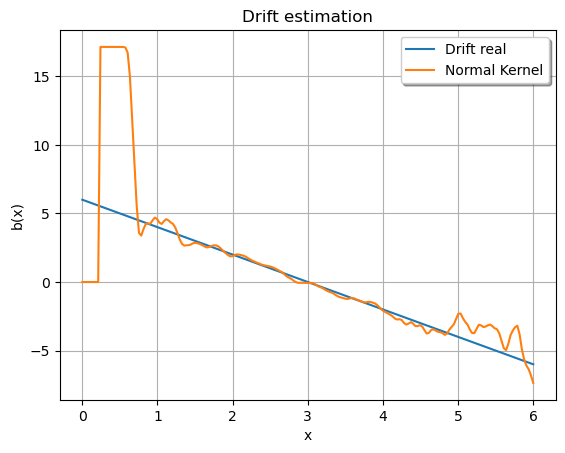

In [13]:
b_data = CIRp.bxt(x_data, 0, CIRp.params)

plt.plot(x_data, b_data, label = 'Drift real')


driftke = DriftKernelEstimator(x_data, x_data_CIR.flatten(), T/Nt, 'normal')
plt.plot(x_data, driftke, label = 'Normal Kernel')

#driftke = DriftKernelEstimator(x_data, x_data_CIR.flatten(), T/Nt, 'parabolic')
#plt.plot(x_data, driftke, label = 'Parabolic Kernel')

#driftke = DriftKernelEstimator(x_data, x_data_CIR.flatten(), T/Nt, 'uniform')
#plt.plot(x_data, driftke, label = 'Uniform Kernel')

plt.title("Drift estimation")
plt.legend(loc = 'best', fancybox = True, shadow = True)
plt.xlabel("x")
plt.ylabel("b(x)")
plt.grid(True)
plt.show()

# Задачи

Задача 1. Оценивание стационарной плотности ансамбля
1. Для модели CIR или OU сгенерируйте траекторию процесса с большим финальным временем $T$ для достижения стационарного режима.

2. Реализуйте функцию `StationaryDistributionKernelEstimator`.

3. Постройте на одном графике теоретическую стационарную плотность $π(x)$ и три ядерные оценки с использованием различных ядер: гауссовского, равномерного и Епанечникова (параболического).

4. Сделайте выводы.


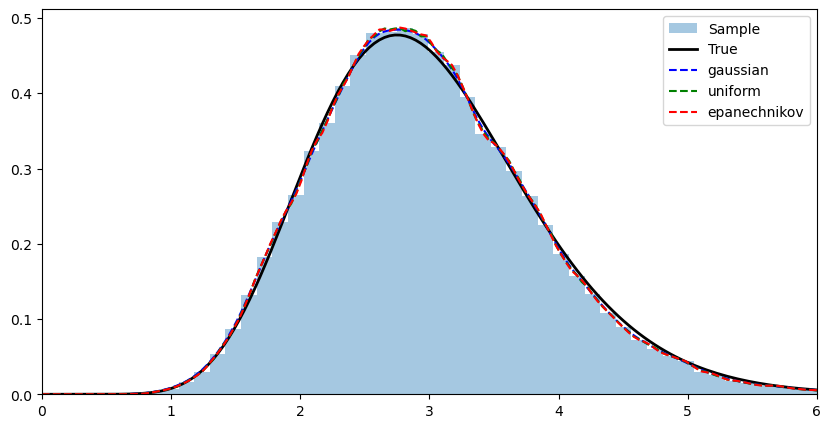

In [14]:
# Генерация данных
CIRp = CIRprocess([6,2,1], T=1000, Nx=1, Nt=100000)
CIRp.init_state = CIRp.StationaryState()
_, X = CIRp.ExactSolution()
X = X.flatten()

# Модифицируем оценщик для разных ядер
def kde(x, X, kernel='gaussian', h=None):
    h = h or np.std(X) * len(X)**(-1/5)
    pi = np.zeros_like(x)
    for i, xi in enumerate(x):
        z = (xi - X) / h
        if kernel == 'gaussian':      K = np.exp(-0.5*z**2) / np.sqrt(2*np.pi)
        elif kernel == 'uniform':     K = 0.5 * (np.abs(z) <= 1)
        elif kernel == 'epanechnikov': K = 0.75 * (1 - z**2) * (np.abs(z) <= 1)
        pi[i] = np.mean(K) / h
    return pi

# График
x_grid = np.linspace(0, 8, 200)
plt.figure(figsize=(10,5))
plt.hist(X, bins=60, density=True, alpha=0.4, label='Sample')
plt.plot(x_grid, CIRp.StationaryDistribution(x_grid), 'k-', lw=2, label='True')
for k, c in [('gaussian','b'), ('uniform','g'), ('epanechnikov','r')]:
    plt.plot(x_grid, kde(x_grid, X, k), '--', c=c, label=k)
plt.xlim(0,6); plt.legend(); plt.show()


Задача 2. Исследование правила Скотта и ширины окна

1. Вычислите оптимальную ширину окна $h_n$ по **правилу Скотта**, где $h_n \propto d \cdot n^{-1/5}$.

2. Постройте 3D-график зависимости ошибки аппроксимации (MSE) от ширины окна $h_n$ и шага дискретизации данных $\Delta_n$.

3. Проверьте утверждение, что при $n \to \infty$ и $h_n \to 0$ оценка сходится к истинной плотности.

4. Сделайте выводы.



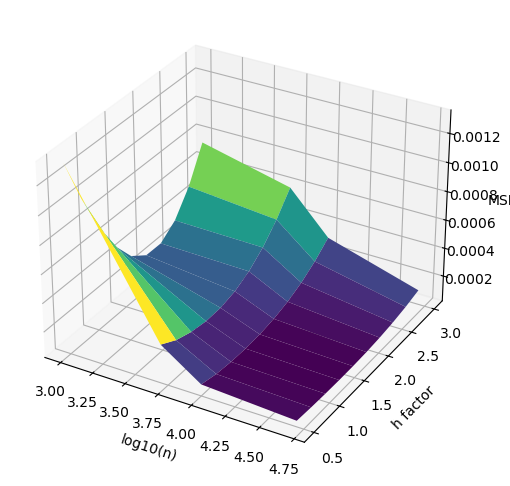

In [15]:
# Сетка параметров и расчёт MSE
n_vals = [1000, 5000, 10000, 50000]
h_factors = np.linspace(0.5, 3, 10)
x_grid = np.linspace(0, 8, 200)
true_pdf = CIRp.StationaryDistribution(x_grid)
MSE = np.zeros((len(n_vals), len(h_factors)))

for i, n in enumerate(n_vals):
    h_scott = np.std(X[:n]) * n**(-1/5)
    for j, f in enumerate(h_factors):
        pdf_est = kde(x_grid, X[:n], h=f*h_scott)
        MSE[i,j] = np.mean((true_pdf - pdf_est)**2)

# 3D-график
fig = plt.figure(figsize=(10,6))
ax = fig.add_subplot(111, projection='3d')
N, H = np.meshgrid(np.log10(n_vals), h_factors, indexing='ij')
ax.plot_surface(N, H, MSE, cmap='viridis')
ax.set_xlabel('log10(n)'); ax.set_ylabel('h factor'); ax.set_zlabel('MSE')
plt.show()

Задача 3. Непараметрическое "восстановление" коэффициентов СДУ


1. Используя оценки Флоренс-Змиру для сноса $\hat{b}_n(x)$ и диффузии $\hat{\sigma}^2_n(x)$ реализуйте функции `DriftKernelEstimator` и `DiffusionKernelEstimator`.

2. Постройте графики восстановленных коэффициентов в сравнении с истинными функциями $b(x)$ и $\sigma(x)$, заложенными в модели.

3. Оцените влияние «шумности» данных на краях области определения, где данных для усреднения недостаточно.

4. Сделайте выводы.


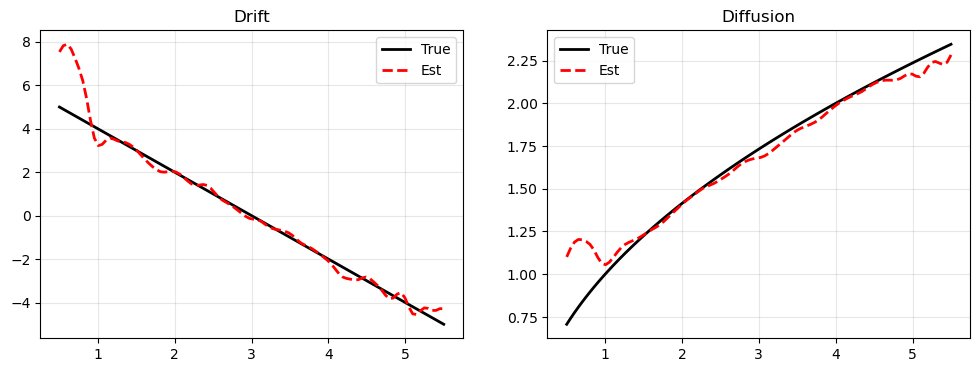

In [16]:
def est_coef(x_grid, X, dt):
    n = len(X); h = np.std(X) * n**(-1/5)
    dX = np.diff(X)
    b, s2 = np.zeros_like(x_grid), np.zeros_like(x_grid)
    
    for i, x in enumerate(x_grid):
        z = (x - X[:-1]) / h
        K = np.exp(-0.5*z**2)
        sumK = np.sum(K)
        if sumK > 0:
            b[i] = np.sum(K * dX) / (sumK * dt)
            s2[i] = np.sum(K * dX**2) / (sumK * dt)
    return b, np.sqrt(np.maximum(s2, 0))

# Оценка и график
x_grid = np.linspace(0.5, 5.5, 100)
b_est, s_est = est_coef(x_grid, X, T/Nt)

fig, (ax1, ax2) = plt.subplots(1,2,figsize=(12,4))
ax1.plot(x_grid, CIRp.bxt(x_grid,0,[6,2,1]), 'k-', lw=2, label='True')
ax1.plot(x_grid, b_est, 'r--', lw=2, label='Est')
ax1.set_title('Drift'); ax1.legend(); ax1.grid(True, alpha=0.3)

ax2.plot(x_grid, CIRp.sigmaxt(x_grid,0,[6,2,1]), 'k-', lw=2, label='True')
ax2.plot(x_grid, s_est, 'r--', lw=2, label='Est')
ax2.set_title('Diffusion'); ax2.legend(); ax2.grid(True, alpha=0.3)
plt.show()


Задача 4. Проверка условий перемешивания (Mixing)

1.  Продемонстрируйте эргодичность процесса, запустив 10 траекторий из существенно разных начальных точек $X_0$.

2. Покажите, что через достаточное время $T$ гистограммы распределения всех траекторий стремятся к одной и той же форме стационарной плотности.
Приведите необходимые иллюстративные графики.

3. Сделайте выводы.



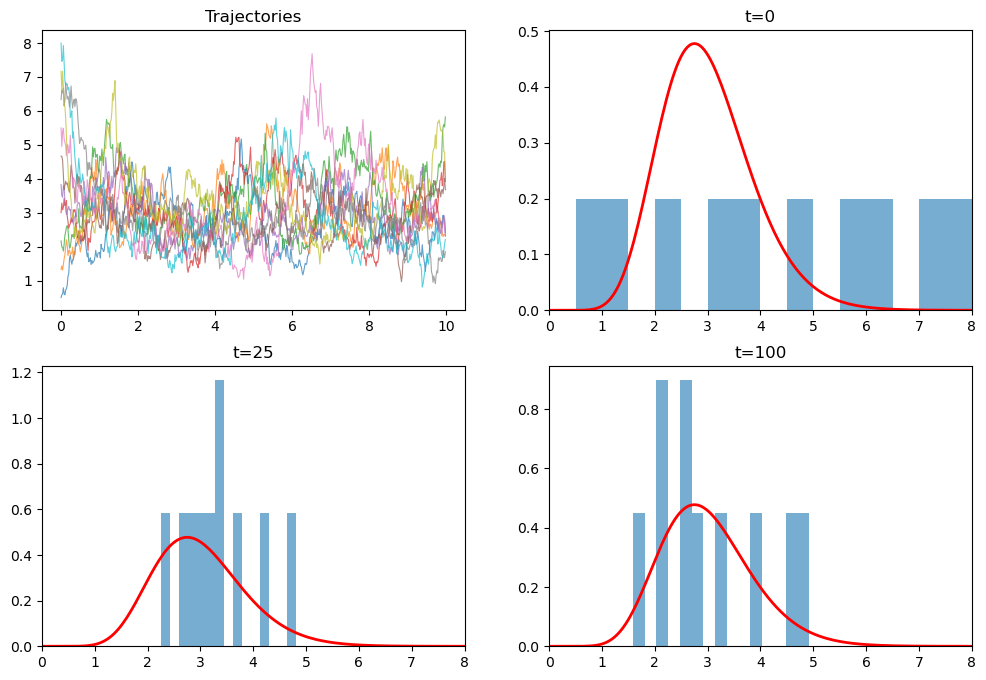

In [17]:
# Генерация 10 траекторий из разных начальных точек
CIRp = CIRprocess([6,2,1], T=100, Nx=10, Nt=5000)
CIRp.init_state = np.linspace(0.5, 8, 10)
t, X_all = CIRp.ExactSolution()

fig, axes = plt.subplots(2,2,figsize=(12,8))
x_grid = np.linspace(0, 8, 200)
true_pdf = CIRp.StationaryDistribution(x_grid)

# Траектории
axes[0,0].plot(t[:500], X_all[:500], alpha=0.7, lw=0.8)
axes[0,0].set_title('Trajectories')

# Распределения в разные моменты времени
for ax, idx, title in [(axes[0,1], 0, 't=0'), 
                       (axes[1,0], 1250, 't=25'), 
                       (axes[1,1], -1, 't=100')]:
    ax.hist(X_all[idx], bins=15, density=True, alpha=0.6)
    ax.plot(x_grid, true_pdf, 'r-', lw=2)
    ax.set_title(title); ax.set_xlim(0,8)
plt.show()

Задача 5. Статистическая верификация качества

1.   Примените критерий **Колмогорова-Смирнова** для сравнения выборки из симуляции и теоретического стационарного распределения.

2.  Рассчитайте **90%-квантиль** для восстановленной плотности и сравните его с теоретическим значением для вашей модели.

3. Сделайте выводы.


In [19]:
from scipy import stats
from scipy.optimize import root_scalar

# Критерий Колмогорова-Смирнова
stat_sample = CIRp.StationaryState()
ks_stat, p_val = stats.ks_2samp(X[-10000:], stat_sample)
print(f"KS test: statistic={ks_stat:.3f}, p-value={p_val:.3f}")
print("=> Распределения неразличимы" if p_val > 0.05 else "=> Различаются")

# Квантиль 90%
q90_emp = np.quantile(X, 0.9)
def cdf_diff(x): 
    x_fine = np.linspace(0, x, 500)
    return np.trapezoid(CIRp.StationaryDistribution(x_fine), x_fine) - 0.9
q90_theo = root_scalar(cdf_diff, bracket=[0, 10]).root
print(f"\n90% квантиль: эмпирический={q90_emp:.3f}, теоретический={q90_theo:.3f}")

KS test: statistic=0.286, p-value=0.323
=> Распределения неразличимы

90% квантиль: эмпирический=4.108, теоретический=4.150
